IMPORTING LIBRARIES


In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

LOAD THE DATA SET

In [230]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [231]:
df.shape

(5000, 13)

In [232]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [233]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [234]:
df.duplicated().sum()

np.int64(2)

In [235]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB


In [236]:
#we will not perform encoding on mental health score which
#is already in float but string type will be done in encoding

In [237]:
df.describe()
#value coming in negative which will be fix in data cleaning step

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


EDA

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

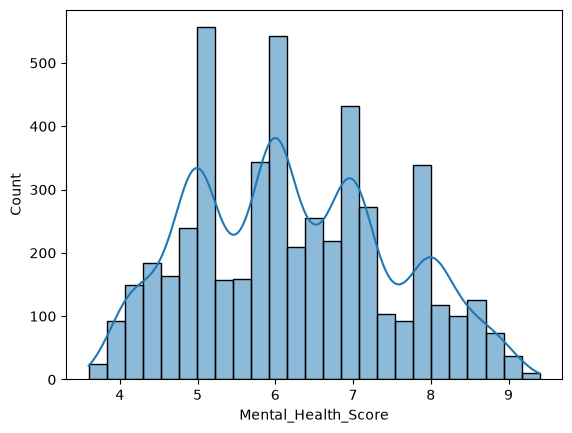

In [238]:
#distribution of the target
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

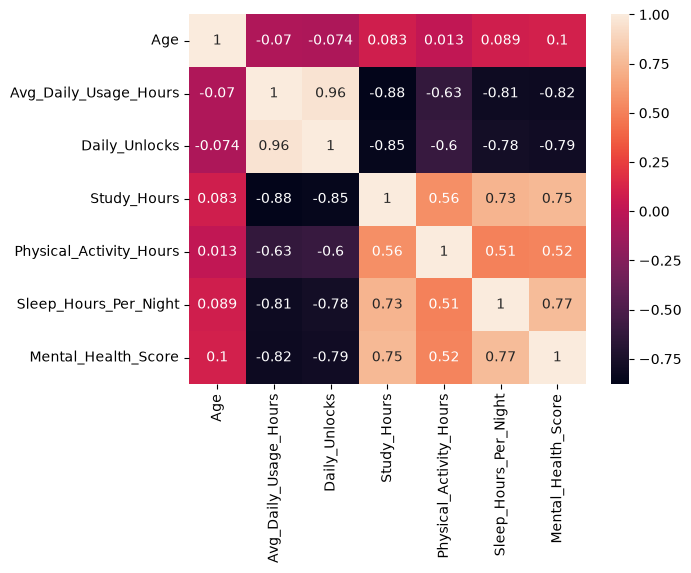

In [239]:
#correlation heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [240]:
#stress level vs mental health score
df['Stress_Level'].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

In [241]:
order = ['Low','Medium','High','Very High']

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

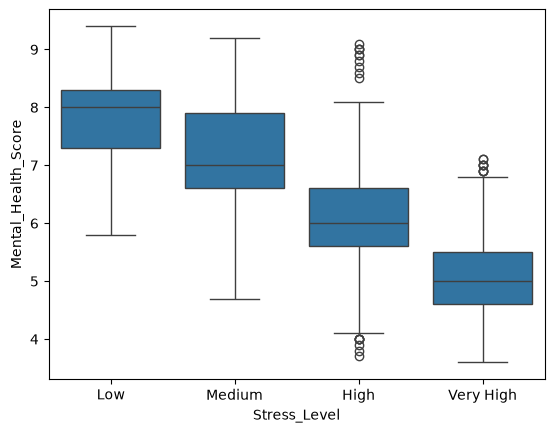

In [242]:
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

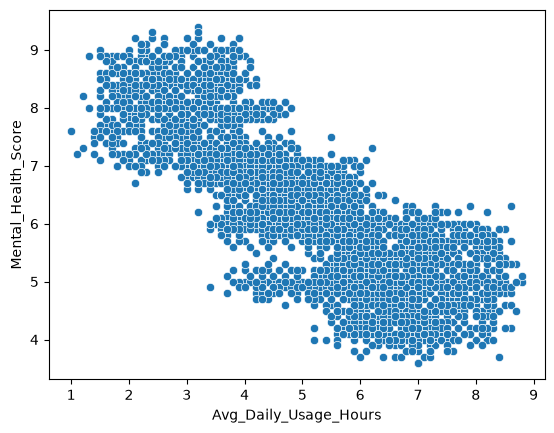

In [243]:
#daily usage hours vs mental health score
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

In [244]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

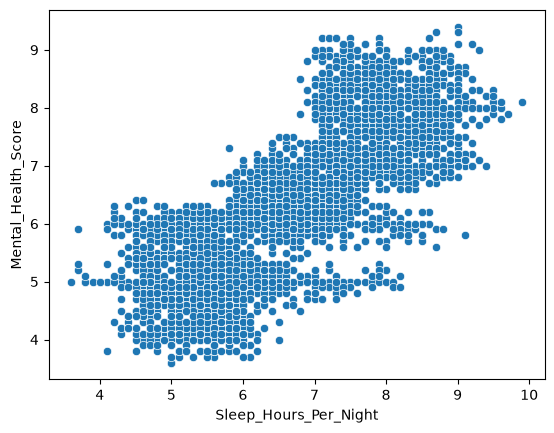

In [245]:
#sleephours vs mentalhealthscore
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)

In [246]:
#most used platform(count)
platform_counts = df['Most_Used_Platform'].value_counts()
platform_counts

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

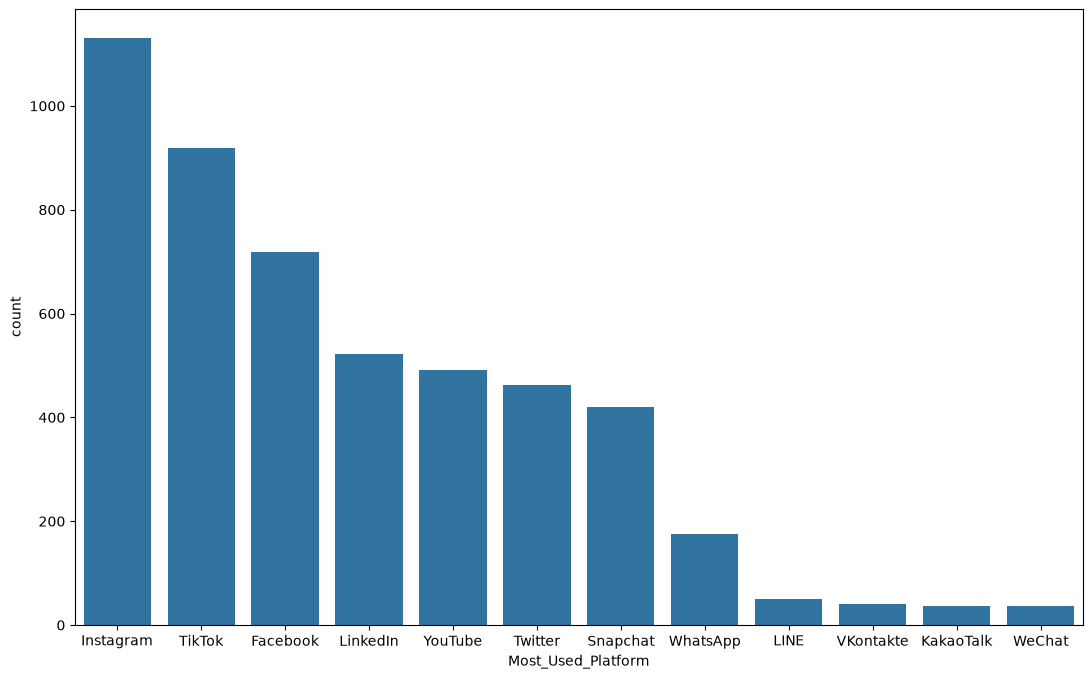

In [247]:
plt.figure(figsize=(13,8))
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

**checking outliers**

In [248]:
num_features = df.select_dtypes(include='number') #int64 or float64
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR  = Q3-Q1

lower_bound = Q1 - 1.5*IQR #lowerbound se niche jo value hai vo galat value hai 
upper_bound = Q3 + 1.5*IQR #upperbound se upar jo value hai vo galat value hai

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


**DATA CLEANING**

In [249]:
#to drop duplicates
df = df.drop_duplicates()

#negative values remove karege
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

#the data has been taken from kaggle which is almost cleaned thats why
#we didn't need to clean the data more.

**SKEWNESS**

In [250]:
#agar ek taarf ka distribution jyaada hota hai toh model
#bhi vahi bhaagta hai toh if we use linear regression 
#but raandom forst doesn't care about skew

In [251]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()
#near to 0 - centralized
#negative -  left skewed 
#greater than 0 - righ skewed

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

**FEATURE ENGINEERING**

we perform this on country because if we performed one hot encoding on this we get so much numbers which can affect our machines efficiency so we grouped countries

In [252]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [253]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [254]:
df['grouped_country'] = df['Country'].apply(group_countries)

In [255]:
df['grouped_country'].value_counts()

grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

**ENCODING**

**TRAIN TEST SPLIT**

#we split before any preprocessing - this is the single most 
#beginner mistake called data leakage
#we will avoid it by fitting evrything only on the training set

In [256]:
from sklearn.model_selection import train_test_split

skewed_column = ['Study_Hours'] #we will performd log transmission on this one sabse jyada skew hai
other_numeric_cols = ['Age','Avg_Daily_Usage_Hours', 'Daily_Unlocks',
'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
#we will perform here standard scaler

ordinal_col = ['Stress_Level'] #label encoding
normal_col = ['Gender','Academic_Level','Most_Used_Platform',
              'Purpose_Of_Use','grouped_country'] #one hot encoding

the above four columns  which are maintained by the column transformer and we used them to prevent from data leakege. column transfromer tells which data will go in which pipeline

In [257]:
feature_col = skewed_column + other_numeric_cols + ordinal_col + normal_col
X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.30, random_state=42)

**PREPROCESSING USING COLUMMN TRANSFORMER**

In [258]:
#import pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder

#now lets create pipeline
#1.pipeline for skewed features
skewed_pipeline = Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
])

#2.numeric feature pipeline
numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

#3.ordinal feature pipeline
ordinal_pipeline = Pipeline(steps=[
    ('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

#4.normal feature pipeline
normal_pipeline = Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])

now we use column transformer who will tell pipelines where to perform

In [259]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    #(konsi pipeline , konsi feature)
    ("skew_pipeline",skewed_pipeline,skewed_column),
    ("plain_numeric",numeric_pipeline,other_numeric_cols),
    ("ordinal",ordinal_pipeline,ordinal_col),
    ("normal",normal_pipeline,normal_col)
])
#knsi pipeline me konsa feature jaan ahai

**NOW WE BUILD PIPELINE FOR MODEL**

**MODEL BUILDING**

In [ ]:
#1) baseline - linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor ),
    ('regression',LinearRegression())
])
lr_pipeline.fit(X_train,y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

#upar jo preprocesssor banaya h jab bhi koi data aayega vo vahi se gujara 
#and tab hamara linear regre. pe jayega

lr_pipeline_r2_testing = r2_score(y_test,lr_pred)

lr_pipeline_r2_training = r2_score(y_train,lr_pred_train)

lr_mae = mean_absolute_error(y_test,lr_pred)

print(f"Accuracy of training {lr_pipeline_r2_training}")
print(f"Accuracy of testing {lr_pipeline_r2_testing}")
print(f"mae {lr_mae}")

Accuracy of training 0.7236771199387539
Accuracy of testing 0.7397944617433021
mae 0.5361775634720182


In [270]:
#2) random forest
from sklearn.ensemble import RandomForestRegressor

rf_pipeline  = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("random forest", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train,y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_pred_training = rf_pipeline.predict(X_train)

rf_r2_test = r2_score(y_test,rf_preds)
rf_r2_train = r2_score(y_train, rf_pred_training)
rf_mae = mean_absolute_error(y_test,rf_preds)

print(f"accuracy of training {rf_r2_train}")
print(f"accuracy of testing {rf_r2_test}")
print(f"accuracy of mae {rf_mae}")

#testing actually matters which used

accuracy of training 0.9809069341581819
accuracy of testing 0.8780167461546369
accuracy of mae 0.34650236666666673


In [272]:
#3) hyperparameter tuning the random forest 
# we used hyperparameter to enhance random forest
# by adding more trees, properties etc.

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators' : [100,200,300], #no of trees
    #random forest__ matlab is tupple ke paas jayge estimators
    'random forest__max_depth': [5,10,15],
    'random forest__min_samples_split': [2,5,10],
    'random forest__min_samples_leaf' : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1 #jitne bhi processors frree hi une kaam pe lagado
)

random_search.fit(X_train,y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [273]:
random_search.best_params_

{'random forest__n_estimators': 200,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [275]:
rf_best_pipeline = random_search.best_estimator_
rf_best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('random forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Study_Hours','Age','Avg_Daily_Usage_Hours',...,'Most_Used_Platform', 'Purpose_Of_Use','grouped_country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_pipeline', ...), ('plain_numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedt

In [277]:
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f"r2 score for random forest after hyperparameter tuning {r2_score(y_test,rf_best_preds)}")
print(f"mae score for random forest after hyperrparameter tuning {mean_absolute_error(y_test,rf_best_preds)}")

r2 score for random forest after hyperparameter tuning 0.8652257547733472
mae score for random forest after hyperrparameter tuning 0.36866505007865863


**MODEL EVALUATION**

In [280]:
from sklearn.metrics import mean_squared_error

#calculate rmse for linear regression
lr_rmse = np.sqrt(mean_squared_error(y_test,lr_pred))

#calculate rmse for default random forest
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_preds))

#calculate rmse for tuned random forest

rf_tuned_preds = random_search.best_estimator_.predict(X_test)

rf_tuned_rmse = np.sqrt(mean_squared_error(y_test,rf_tuned_preds))

rf_tuned_training_preds  = random_search.best_estimator_.predict(X_train)

r2_tuned_training = r2_score(y_train,rf_tuned_training_preds)

rf_tuned_mae = mean_absolute_error(y_test,rf_tuned_preds)

rf_tuned_r2  = r2_score(y_test , rf_tuned_preds)

#create a dataframe to consolidate results

results = pd.DataFrame({
    'Model':['Linear Regression','Random Forest (default)','Random Forest (tuned)'],
    'R2': [lr_pipeline_r2_testing,rf_r2_test,rf_tuned_r2],
    'Training R2': [lr_pipeline_r2_training,rf_r2_train,r2_tuned_training],
    'MAE':[lr_mae,rf_mae,rf_tuned_mae],
    'RMSE':[lr_rmse,rf_rmse,rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.878017     0.980907  0.346502  0.462870
2    Random Forest (tuned)  0.865226     0.954656  0.368665  0.486533


we need testing so best testing is random forest (default)

**SAVE THE MODEL**

In [281]:
import joblib
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']